<a href="https://colab.research.google.com/github/Ayush5727t/aps-google-colab/blob/main/Lab_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 2. Divide and Conquer (Sorting)

- **Created by Dr. Ajay

Write a python program to perform **Countingsort**.
* Statement:  Given a disordered list of repeated integers, rearrange the integers in natural order.
 Sample Input: [4,3,2,1,4,3,2,4,3,4]
 Sample Output: [1,2,2,3,3,3,4,4,4,4]

Time Complexity of Solution: Best Case O(n+k); Average Case O(n+k); Worst Case O(n+k), where n is the size of the input array and k means the values range from 0 to k.
- Approach:
Counting sort, like radix sort and bucket sort, is an integer based algorithm (i.e. the values of the input array are assumed to be integers). Hence counting sort is among the fastest sorting algorithms around, in theory. The  particular distinction for counting sort is that it creates a bucket for each value and keep a counter in each bucket. Then each time a value is encountered in the input collection, the appropriate counter is incremented. Because counting sort creates a bucket for each value, an imposing restriction is that the maximum value in the input array be known beforehand. Bucket sort uses a hash function to distribute values; counting sort, on the other hand, creates a counter for each value -- hence the name.
- Implementation notes:
1. Since the values range from 0 to k, create k+1 buckets.

2. To fill the buckets, iterate through the input list and
each time a value appears, increment the counter in its bucket.
3. Now fill the input list with the compressed data in the
buckets. Each bucket's key represents a value in the  array. So for each bucket, from smallest key to largest, add the index of the bucket to the input array and decrease the counter in said bucket by one; until the counter is zero.

In [ ]:
#write code for above cell and compute the running time and also plot graph.
def bubble_sort(bucket):
  for i in range(1, len(bucket)-1):
    if bucket[i]>bucket[i+1]:
      temp=bucket[i]
      bucket[i]=bucket[i+1]
      bucket[i+1]=temp


def bucket_sort(a):
  n=len(a)
  barry=[[] for _ in range(n)]


  for i in a:
    bi=int(n*i)
    barry[bi].append(i)
  index=0
  for n in barry:
    bubble_sort(n)
  for n in barry:
    for i in n:
      a[index]=i
      index+=1

arr = [0.897, 0.565,0.56, 0.656, 0.1234, 0.665, 0.3434]
bucket_sort(arr)
print("Sorted array is:")
print(" ".join(map(str, arr)))

Sorted array is:
0.1234 0.3434 0.565 0.56 0.656 0.665 0.897


Sorted list: [0, 1, 2, 3, 4, 5, 5, 6, 7, 8, 9]
Running time: 7.390975952148438e-05 seconds


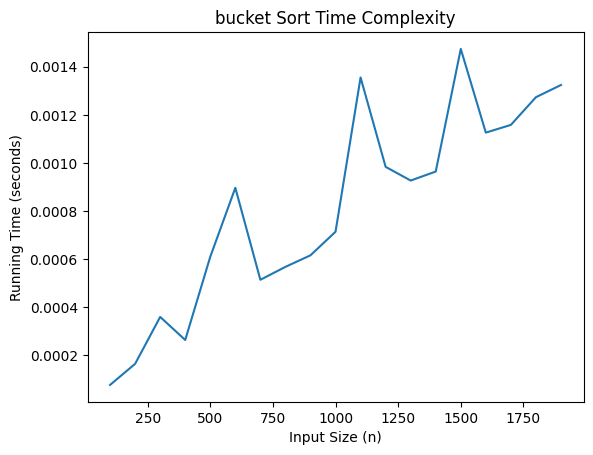

In [ ]:
import time
import matplotlib.pyplot as plt
import random
# ---- Running Time for User Input ----
start = time.time()
bucket_sort(arr)
end = time.time()

print("Sorted list:", arr)
print("Running time:", end - start, "seconds")

# ---- Time Complexity Graph ----
sizes = []
times = []

# Generate a range of input sizes for the graph
for size_val in range(100, 2000, 100):
    # Generate floating-point numbers between 0 and 1 for compatibility with bucket_sort
    test_data = [random.uniform(0, 1) for _ in range(size_val)]
    start_time = time.time()
    bucket_sort(test_data)
    end_time = time.time()
    sizes.append(size_val)
    times.append(end_time - start_time)

plt.plot(sizes, times)
plt.xlabel("Input Size (n)")
plt.ylabel("Running Time (seconds)")
plt.title("bucket Sort Time Complexity")
plt.show()

 - *Bucketsort*
Statement:
Given a disordered list of integers, rearrange them in natural order.
 Sample Input: [8,5,3,1,9,6,0,7,4,2,5]
 Sample Output: [0,1,2,3,4,5,6,7,8,9,5]
Time Complexity of Solution:
Best Case O(n); Average Case O(n); Worst Case O(n).
- Approach:
If it sounds too good to be true, then most likely it's not true. Bucketsort is not an exception to this adage. For bucketsort to
work at its blazing efficiency, there are multiple prerequisites.
First the hash function that is used to partition the elements need
to be very good and must produce ordered hash: if i < k then
hash(i) < hash(k). Second, the elements to be sorted must be
uniformly distributed.
  The aforementioned aside, bucket sort is actually very good
considering that counting sort is reasonably speaking its upper
bound. And counting sort is very fast. The particular distinction
for bucket sort is that it uses a hash function to partition the
keys of the input array, so that multiple keys may hash to the same
bucket. Hence each bucket must effectively be a growable list;
similar to radix sort.


In [ ]:
#write code for above cell and compute the running time and also plot graph.
# Fixed bubble_sort to correctly sort a list
def bubble_sort(bucket):
  n_b = len(bucket)
  for i in range(n_b - 1): # Number of passes
    for j in range(n_b - 1 - i): # Comparison in each pass
      if bucket[j] > bucket[j+1]:
        bucket[j], bucket[j+1] = bucket[j+1], bucket[j]

def bucket_sort(a):
  n = len(a)
  if n == 0:
    return

  min_val = a[0]
  max_val = a[0]
  for x in a:
    if x < min_val:
      min_val = x
    if x > max_val:
      max_val = x

  # If all elements are the same or only one element, no sorting needed by buckets
  if min_val == max_val:
      return # List is already sorted if all elements are identical

  # Determine the range for scaling
  # Add 1 to max_val - min_val to ensure the divisor is never zero and covers the max_val in scaling
  value_range = max_val - min_val + 1

  # Create n buckets
  barry = [[] for _ in range(n)]

  # Distribute elements into buckets
  for i in a:
    # Normalize `i` to be between 0 and less than 1, then scale by n to get a bucket index
    # (i - min_val) gives a value from 0 to max_val - min_val
    # Dividing by value_range maps it to [0, 1)
    # Multiplying by n maps it to [0, n)
    bi = int(((i - min_val) / value_range) * n)

    # Edge case: if i is max_val, ((max_val - min_val) / value_range) * n
    # could become n, which would be out of bounds for barry of size n. Max index is n-1.
    if bi == n:
        bi = n - 1

    barry[bi].append(i)

  # Sort each bucket using the corrected bubble_sort
  for bucket in barry:
    bubble_sort(bucket)

  # Concatenate the sorted buckets back into the original array
  index = 0
  for bucket in barry:
    for element in bucket:
      a[index] = element
      index += 1

arr = [8,5,3,1,9,6,0,7,4,2,5]
bucket_sort(arr)
print("Sorted array is:")
print(" ".join(map(str, arr)))

Sorted array is:
0 1 2 3 4 5 5 6 7 8 9


Sorted list: [0, 1, 2, 3, 4, 5, 5, 6, 7, 8, 9]
Running time: 0.00011491775512695312 seconds


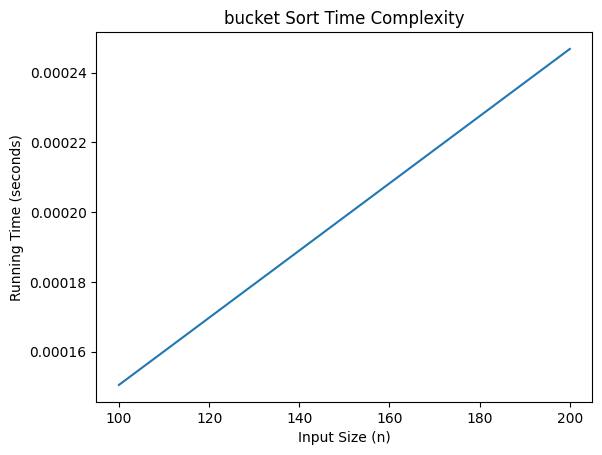

In [ ]:
import time
import matplotlib.pyplot as plt
import random
# ---- Running Time for User Input ----
start = time.time()
bucket_sort(arr)
end = time.time()

print("Sorted list:", arr)
print("Running time:", end - start, "seconds")

# ---- Time Complexity Graph ----
sizes = []
times = []

# Generate a range of input sizes for the graph
for size_val in range(100, 250, 100):
    # Generate floating-point numbers between 0 and 1 for compatibility with bucket_sort
    test_data = [random.uniform(0, 1) for _ in range(size_val)]
    start_time = time.time()
    bucket_sort(test_data)
    end_time = time.time()
    sizes.append(size_val)
    times.append(end_time - start_time)

plt.plot(sizes, times)
plt.xlabel("Input Size (n)")
plt.ylabel("Running Time (seconds)")
plt.title("bucket Sort Time Complexity")
plt.show()

**Radix sort**
Statement:Given a disordered list of integers, rearrange them in natural order.
Sample Input: [18,5,100,3,1,19,6,0,7,4,2]
Sample Output: [0,1,2,3,4,5,6,7,18,19,100]
Time Complexity of Solution:Best Case O(kn); Average Case O(kn); Worst Case O(kn),where k is the length of the longest number and n is the size of the input array.Note: if k is greater than log(n) then an nlog(n) algorithm would be a better fit. In reality we can always change the radix to make k less than log(n).
- Approach: radix sort, like counting sort and bucket sort, is an integer based algorithm (i.e. the values of the input array are assumed to be integers). Hence radix sort is among the fastest sorting algorithms around, in theory. The particular distinction for radix sort is that it creates a bucket for each cipher (i.e. digit); as such, similar to bucket sort, each bucket in radix sort must be a
growable list that may admit different keys. For decimal values, the number of buckets is 10, as the decimal system has 10 numerals/cyphers (i.e. 0,1,2,3,4,5,6,7,8,9). Then the keys are continuously sorted by significant digits.

Sorted array is:
0 1 2 3 4 5 6 7 18 19 100

Sorted list: [0, 1, 2, 3, 4, 5, 6, 7, 18, 19, 100]
Running time for sample input: 0.000186920166015625 seconds


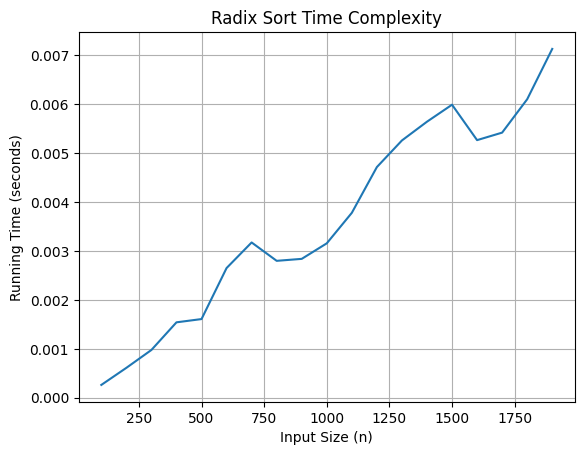

In [2]:
import time
import matplotlib.pyplot as plt
import random

def counting_sort(arr, exp):
    n = len(arr)
    output = [0] * n
    count = [0] * 10

    # Populate count array based on the digit at exp position
    for i in range(n):
        index = (arr[i] // exp) % 10
        count[index] += 1

    # Modify count array to store cumulative counts
    for i in range(1, 10):
        count[i] += count[i - 1]

    # Build the output array
    # Iterate in reverse to ensure stability
    i = n - 1
    while i >= 0:
        index = (arr[i] // exp) % 10
        output[count[index] - 1] = arr[i]
        count[index] -= 1
        i -= 1

    # Copy the sorted elements back to arr
    for i in range(n):
        arr[i] = output[i]

def radix_sort(arr):
    if not arr:
        return

    # Find the maximum number to determine the number of digits
    max_val = max(arr)

    # Start with least significant digit (exp = 1, for units place)
    exp = 1
    while max_val // exp > 0:
        counting_sort(arr, exp)
        exp *= 10

# Sample Input from text cell: [18,5,100,3,1,19,6,0,7,4,2]
arr = [18, 5, 100, 3, 1, 19, 6, 0, 7, 4, 2]
radix_sort(arr)
print("Sorted array is:")
print(" ".join(map(str, arr)))

# ---- Running Time for User Input ----
start_time_single = time.time()
arr_test_single = [18, 5, 100, 3, 1, 19, 6, 0, 7, 4, 2]
radix_sort(arr_test_single)
end_time_single = time.time()

print("\nSorted list:", arr_test_single)
print("Running time for sample input:", end_time_single - start_time_single, "seconds")

# ---- Time Complexity Graph ----
sizes = []
times = []

# Generate a range of input sizes for the graph
for size_val in range(100, 2000, 100):
    test_data = [random.randint(0, 100000) for _ in range(size_val)] # Generate random integers
    start_time_graph = time.time()
    radix_sort(test_data)
    end_time_graph = time.time()
    sizes.append(size_val)
    times.append(end_time_graph - start_time_graph)

plt.plot(sizes, times)
plt.xlabel("Input Size (n)")
plt.ylabel("Running Time (seconds)")
plt.title("Radix Sort Time Complexity")
plt.grid(True)
plt.show()